# 📊 EDA for precautions

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load Dataset
df = pd.read_csv('..//backend/Training/MasterData/precautions_df.csv')
print("Dataset Uploaded Sucessfully!")

Dataset Uploaded Sucessfully!


# 🔎 Dataset Overview

In [3]:
print("🔹 Dataset Shape:", df.shape)
display(df.head())

🔹 Dataset Shape: (40, 5)


,Disease,Precaution_1,Precaution_2,Precaution_3,Precaution_4
0,Drug Reaction,stop irritation,consult nearest hospital,stop taking drug,follow up
1,Malaria,Consult nearest hospital,avoid oily food,avoid non veg food,keep mosquitos out
2,Allergy,apply calamine,cover area with bandage,,use ice to compress itching
3,Hypothyroidism,reduce stress,exercise,eat healthy,get proper sleep
4,Psoriasis,wash hands with warm soapy water,stop bleeding using pressure,consult doctor,salt baths


In [4]:
print("\n🔹 Info:")
df.info()


🔹 Info:
<class 'pandas.core.frame.DataFrame'>
Index: 40 entries, 0 to 40
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Disease       40 non-null     object
 1   Precaution_1  40 non-null     object
 2   Precaution_2  40 non-null     object
 3   Precaution_3  40 non-null     object
 4   Precaution_4  39 non-null     object
dtypes: object(5)
memory usage: 1.9+ KB


In [5]:
print("\n🔹 Column Names:", df.columns.tolist())
print("\n🔹 Data Types:\n", df.dtypes)
print("\n🔹 Missing Values:\n", df.isnull().sum())
print("\n🔹 Duplicate Rows:", df.duplicated().sum())


🔹 Column Names: ['Disease', 'Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']

🔹 Data Types:
 Disease         object
Precaution_1    object
Precaution_2    object
Precaution_3    object
Precaution_4    object
dtype: object

🔹 Missing Values:
 Disease         0
Precaution_1    0
Precaution_2    0
Precaution_3    0
Precaution_4    1
dtype: int64

🔹 Duplicate Rows: 0


In [6]:
# Unique values per column
print("\n🔹 Unique Value Counts:")
print(df.nunique())


🔹 Unique Value Counts:
Disease         40
Precaution_1    31
Precaution_2    33
Precaution_3    31
Precaution_4    23
dtype: int64


In [7]:
display(df.describe(include="all").transpose())

,count,unique,top,freq
Disease,40,40,Drug Reaction,1
Precaution_1,40,31,Consult nearest hospital,3
Precaution_2,40,33,exercise,3
Precaution_3,40,31,consult doctor,6
Precaution_4,39,23,follow up,6



=== Univariate Analysis ===


C:\Users\hp\AppData\Local\Temp\ipykernel_12896\1676654419.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


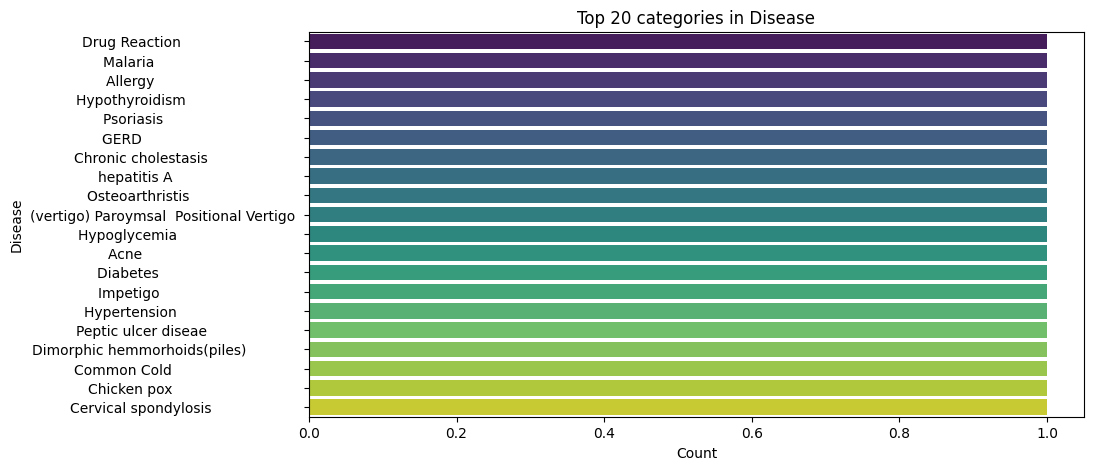

C:\Users\hp\AppData\Local\Temp\ipykernel_12896\1676654419.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


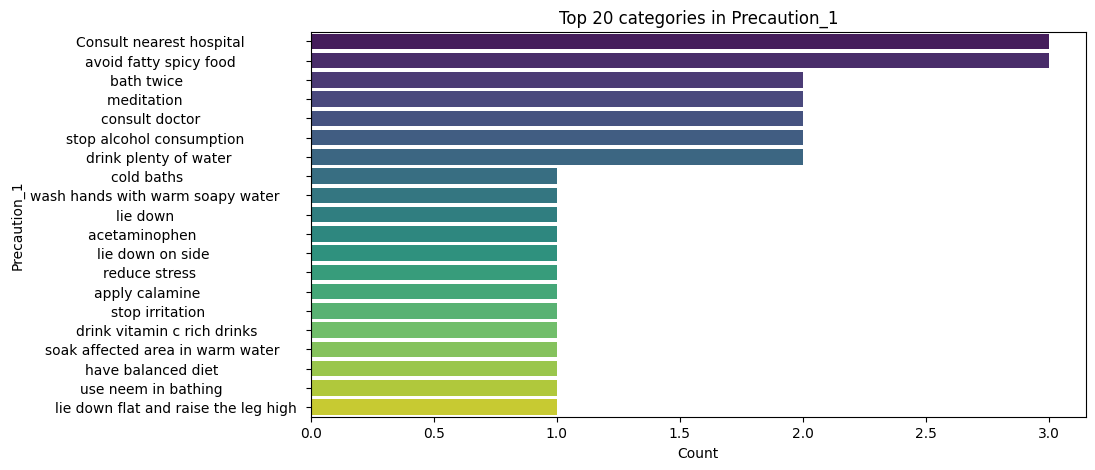

C:\Users\hp\AppData\Local\Temp\ipykernel_12896\1676654419.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


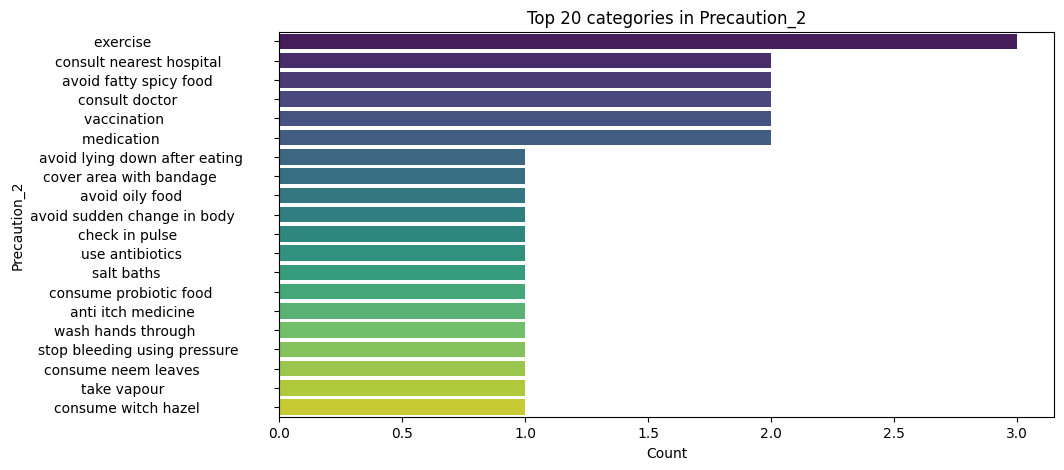

C:\Users\hp\AppData\Local\Temp\ipykernel_12896\1676654419.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


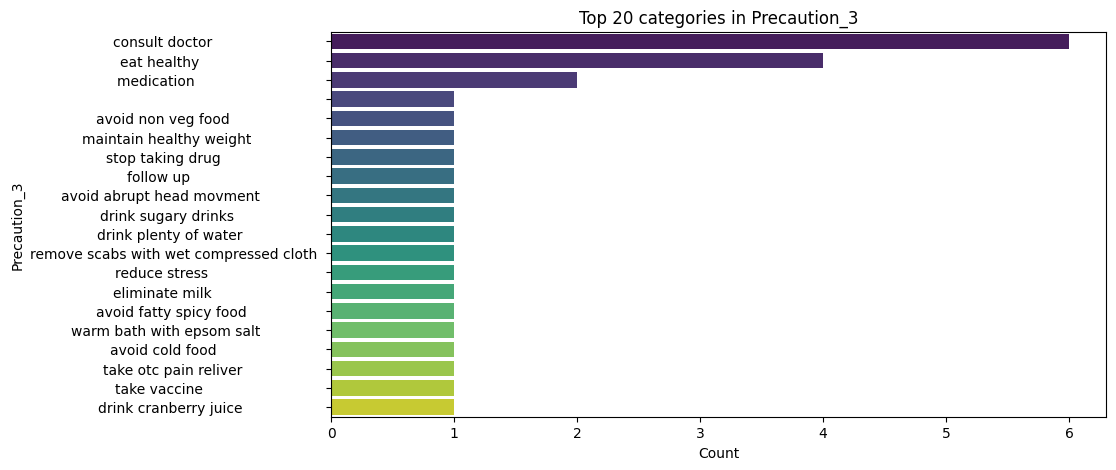

C:\Users\hp\AppData\Local\Temp\ipykernel_12896\1676654419.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")


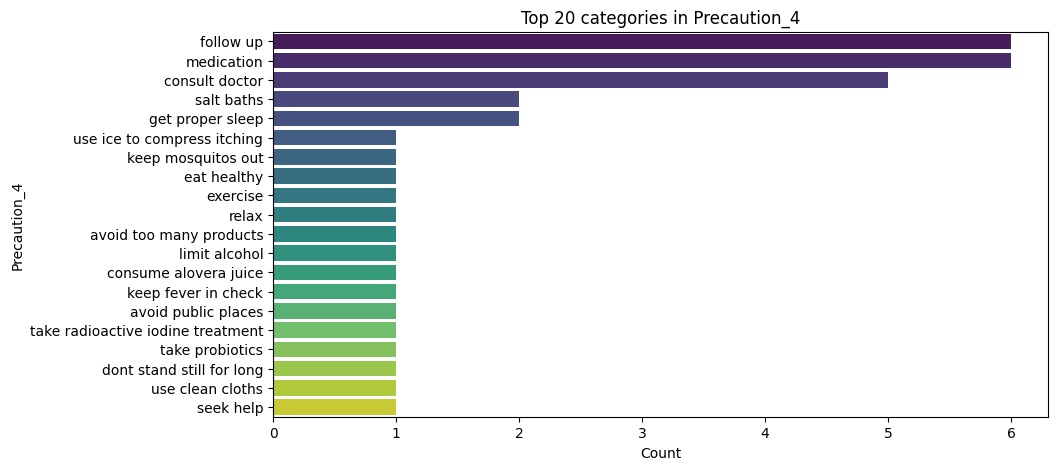

In [8]:
print("\n=== Univariate Analysis ===")

for col in df.columns:
    plt.figure(figsize=(10,5))
    if df[col].dtype == 'object':
        top_vals = df[col].value_counts().head(20)
        sns.barplot(y=top_vals.index, x=top_vals.values, palette="viridis")
        plt.title(f"Top 20 categories in {col}")
        plt.xlabel("Count")
        plt.ylabel(col)
        plt.show()
    else:
        sns.histplot(df[col], kde=True, bins=30, color="royalblue")
        plt.title(f"Distribution of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()


=== Boxplots for Each Feature ===


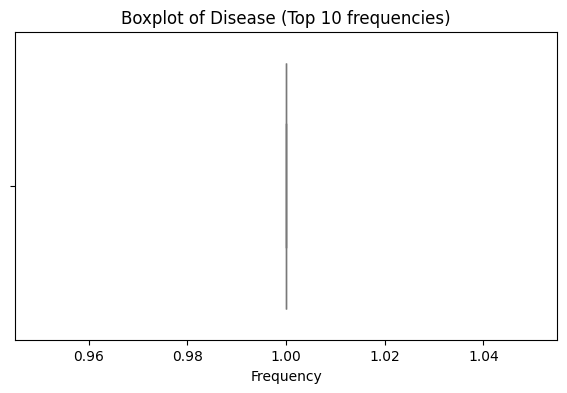

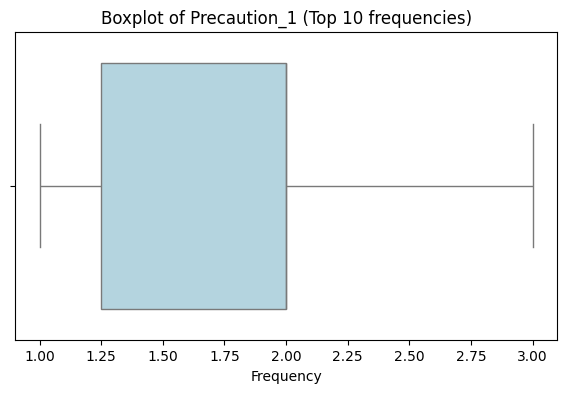

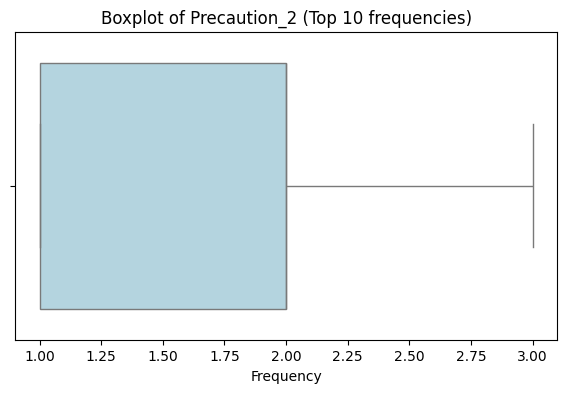

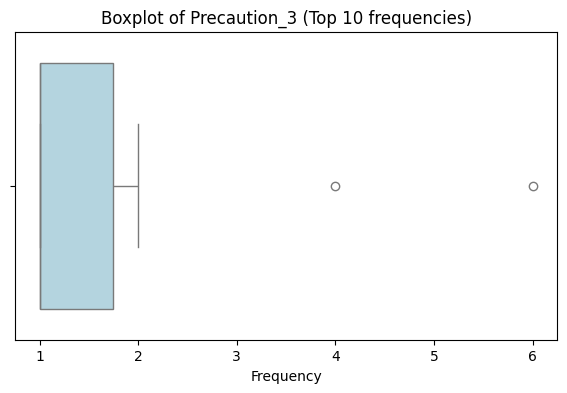

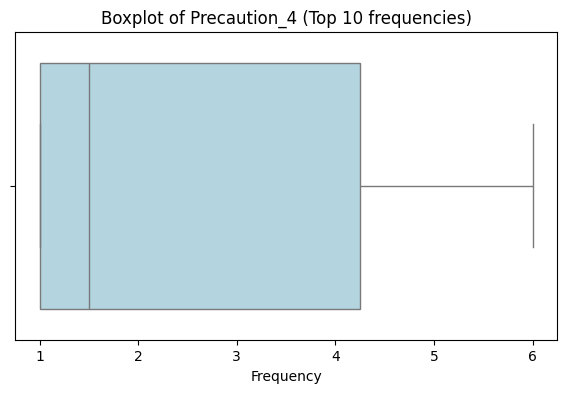

In [9]:
# Boxplots for Each Feature
print("\n=== Boxplots for Each Feature ===")

for col in df.columns:
    plt.figure(figsize=(7,4))
    if df[col].dtype != 'object':  # numeric features
        sns.boxplot(x=df[col], color="orange")
        plt.title(f"Boxplot of {col}")
        plt.xlabel(col)
        plt.show()
    else:  # categorical features (frequency distribution shown as boxplot of counts)
        top_vals = df[col].value_counts().head(10)
        sns.boxplot(x=top_vals.values, color="lightblue")
        plt.title(f"Boxplot of {col} (Top 10 frequencies)")
        plt.xlabel("Frequency")
        plt.show()

In [10]:
# Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
if len(numeric_cols) > 1:
    plt.figure(figsize=(10,6))
    corr = df[numeric_cols].corr()
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap")
    plt.show()

In [11]:
# Crosstab for categorical columns
cat_cols = df.select_dtypes(include=['object']).columns
if len(cat_cols) >= 2:
    for i in range(len(cat_cols)-1):
        ct = pd.crosstab(df[cat_cols[i]], df[cat_cols[i+1]])
        print(f"\n🔹 Crosstab between {cat_cols[i]} and {cat_cols[i+1]}:\n", ct.head())


🔹 Crosstab between Disease and Precaution_1:
 Precaution_1                              Consult nearest hospital               \
Disease                                                                           
(vertigo) Paroymsal  Positional Vertigo                                       0   
AIDS                                                                          0   
Acne                                                                          0   
Alcoholic hepatitis                                                           0   
Allergy                                                                       0   

Precaution_1                              acetaminophen                          \
Disease                                                                           
(vertigo) Paroymsal  Positional Vertigo                                       0   
AIDS                                                                          0   
Acne                                   

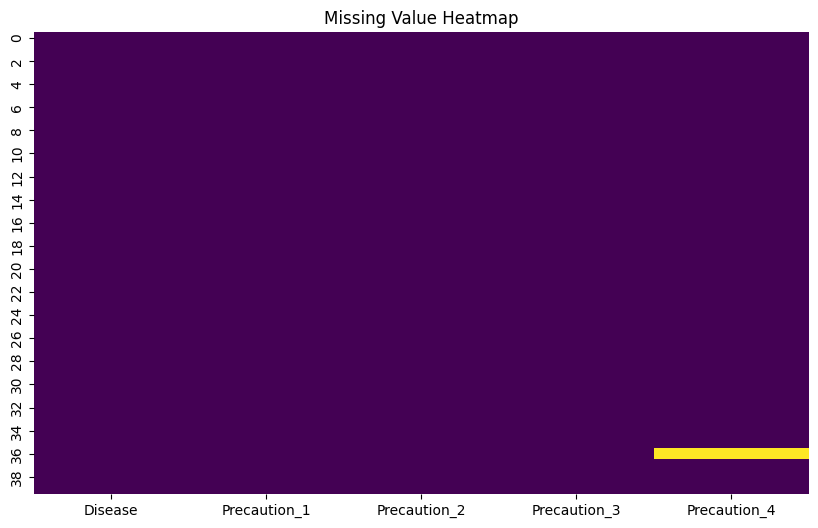

In [12]:
# Missing Data Visualization
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Heatmap")
plt.show()


### EDA Completed Successfully!